In [2]:
import os
import pandas as pd
import seaborn as sns
import numpy as np
import random
from matplotlib import pyplot as plt
from datetime import datetime
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

In [26]:
# 뮤지컬 csv
data1 = pd.read_excel('../data/raw/musical_rating.xlsx')
data1 = data1.drop(data1.columns[0], axis=1)
data1.head()

,Title,ID,Star,Date
0,뮤지컬 〈레베카〉 10주년 기념공연,psj022***,5,2023.10.12
1,뮤지컬 〈레베카〉 10주년 기념공연,psj022***,5,2023.10.12
2,뮤지컬 〈레베카〉 10주년 기념공연,leesm1***,5,2023.10.12
3,뮤지컬 〈레베카〉 10주년 기념공연,privacy***,5,2023.10.12
4,뮤지컬 〈레베카〉 10주년 기념공연,imvely1***,5,2023.10.12


In [4]:
len(data1)

12563

In [5]:
n_user = len(data1['ID'].unique())    # 유저 수
n_movie = len(data1['Title'].unique())    # 영화 수

print('유저 수 :', n_user, '영화 수 :', n_movie)

# 평점 데이터 정보
data1.info()

유저 수 : 5959 영화 수 : 38
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12563 entries, 0 to 12562
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Title   12563 non-null  object
 1   ID      12563 non-null  object
 2   Star    12563 non-null  int64 
 3   Date    12563 non-null  object
dtypes: int64(1), object(3)
memory usage: 392.7+ KB


In [6]:
data1[['Star']].describe()

,Star
count,12563.000000
mean,4.851071
std,0.514737
min,1.000000
25%,5.000000
50%,5.000000
75%,5.000000
max,5.000000


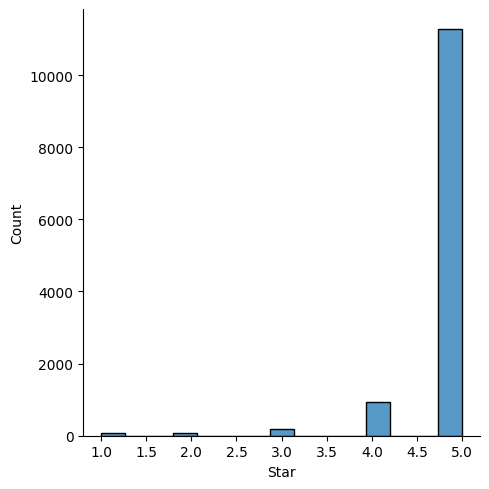

In [7]:
sns.displot(data1['Star'])

In [8]:
movie_statistics1 = pd.DataFrame({
    'numUsers': data1.groupby('Title')['ID'].nunique(),
    'avgRating': data1.groupby('Title')['Star'].mean(),
    'stdRating': data1.groupby('Title')['Star'].std()
}).reset_index()

movie_statistics1

,Title,numUsers,avgRating,stdRating
0,난타(NANTA) - 명동공연,150,4.851852,0.475776
1,더 맨 얼라이브 〈초이스〉,106,4.848315,0.650530
2,뮤지컬 〈22년 2개월〉,349,4.826000,0.469217
3,뮤지컬 〈곤 투모로우〉,366,4.894000,0.441763
4,뮤지컬 〈구텐버그〉,351,4.918000,0.345709
5,뮤지컬 〈김종욱 찾기〉,176,4.852018,0.475132
6,뮤지컬 〈레베카〉 10주년 기념공연,427,4.840000,0.578852
7,뮤지컬 〈렛미플라이〉,275,4.924925,0.506355
8,뮤지컬 〈멤피스〉,391,4.868000,0.459345
9,뮤지컬 〈문스토리〉,232,4.849817,0.495726


In [9]:
top10_df_1 = movie_statistics1.sort_values(by='numUsers', ascending=False)[:10]
top10_df_1.head()

,Title,numUsers,avgRating,stdRating
6,뮤지컬 〈레베카〉 10주년 기념공연,427,4.840000,0.578852
32,뮤지컬 ＇벤허＇,419,4.892929,0.410700
16,뮤지컬 〈오페라의 유령〉 - 서울,417,4.754000,0.659054
26,뮤지컬 〈프리다〉,400,4.782000,0.680737
8,뮤지컬 〈멤피스〉,391,4.868000,0.459345


## 장르

In [10]:
play1 = pd.read_excel('../data/raw/musical_merged.xlsx')
play1 = play1.drop(play1.columns[0], axis=1)
play1 = play1.drop(play1.columns[2], axis=1)
play1.head()

,Title,Text_clear_num,공연소개,장르
0,"2023 〈스웨그에이지 : 외쳐, 조선〉 - 인천",인기 우리의 작은 외침이 세상을 바꾼파 우리의 작은 외침이 세상을 바꾼다 우리들의 ...,NaN,역사극
1,2023 이은결 더 일루션 마스터피스 - 이천,케 티토 으으으 빨 게숫으오거 림 보이저 니거 법 존 이천아트홀 주간 전기차 제자 ...,NaN,판타지
2,2023 창작뮤지컬어워드 NEXT,창작뮤지컬어워드 충무마트센터가 가능성 있는 참작뮤지컬 발굴을 플랫품인 창작뮤지컬머워...,None,드라마
3,2023 최현우 Answer - 대구,구수성아트피아 대극장 년간의 마술 노하우를 집대성한 완결판 친혀으 미술시로컬어온 여...,NaN,판타지
4,2023 최현우 Answer - 성남,적 서니 정남아트센터 오페라하우스 이하늘이엔티 빅탑엔터테인언트 지라온플레이 년간의 ...,NaN,판타지


In [11]:
play1['장르']

0           역사극
1           판타지
2           드라마
3           판타지
4           판타지
         ...   
151    로맨스, 판타지
152    역사극, 드라마
153    드라마, 판타지
154     판타지, 액션
155    드라마, 역사극
Name: 장르, Length: 156, dtype: object

In [12]:
play1['장르'] = play1['장르'].str.replace('코미디', '코믹')

In [13]:
genre_mapping = {
    '감동': 0,
    '공포': 1,
    '드라마': 2,
    '로맨스': 3,
    '미스터리': 4,
    '성인용': 5,
    '스릴러': 6,
    '액션': 7,
    '역사극': 8,
    '종교': 9,
    '코믹': 10,
    '판타지': 11,
    '콘서트' : 12
}

# 장르를 숫자로 인코딩한  장르_e 변수 생성
play1['장르_e'] = play1['장르'].apply(lambda x: [genre_mapping.get(genre, -1) for genre in x.split(', ')])

In [14]:
play1.head(3)

,Title,Text_clear_num,공연소개,장르,장르_e
0,"2023 〈스웨그에이지 : 외쳐, 조선〉 - 인천",인기 우리의 작은 외침이 세상을 바꾼파 우리의 작은 외침이 세상을 바꾼다 우리들의 ...,NaN,역사극,[8]
1,2023 이은결 더 일루션 마스터피스 - 이천,케 티토 으으으 빨 게숫으오거 림 보이저 니거 법 존 이천아트홀 주간 전기차 제자 ...,NaN,판타지,[11]
2,2023 창작뮤지컬어워드 NEXT,창작뮤지컬어워드 충무마트센터가 가능성 있는 참작뮤지컬 발굴을 플랫품인 창작뮤지컬머워...,None,드라마,[2]


In [16]:
# 인코딩이 제대로 안 된 경우가 있는지 확인

genres = play1['장르_e']

count_of_ones = sum(genre_list.count(-1) for genre_list in genres)

print("Count of -1s:", count_of_ones)

Count of -1s: 0


In [17]:
rows_with_minus_1 = [i for i, genre_list in enumerate(play1['장르_e']) if -1 in genre_list]
filtered_rows = play1.iloc[rows_with_minus_1]

print(filtered_rows[['Title', '장르_e']])

Empty DataFrame
Columns: [Title, 장르_e]
Index: []


In [ ]:
## 장르 인코딩 - 원데이터 합치기

In [18]:
data_f = pd.merge(data1, play1[['Title','장르', '장르_e']], on='Title')

data1['장르'] = data_f['장르']
data1['장르_e'] = data_f['장르_e']
data1.head(3)

,Title,ID,Star,Date,장르,장르_e
0,뮤지컬 〈레베카〉 10주년 기념공연,psj022***,5,2023.10.12,"스릴러, 미스터리, 로맨스","[6, 4, 3]"
1,뮤지컬 〈레베카〉 10주년 기념공연,psj022***,5,2023.10.12,"스릴러, 미스터리, 로맨스","[6, 4, 3]"
2,뮤지컬 〈레베카〉 10주년 기념공연,leesm1***,5,2023.10.12,"스릴러, 미스터리, 로맨스","[6, 4, 3]"


In [19]:
data1.to_excel("../data/raw/musical_rating_final.xlsx", sheet_name='Sheet1')

## Steam Rating

In [ ]:
# SteamRating이 높은 순서대로 정렬

movie_statistics1['steamRating'] = movie_statistics1['avgRating'] - (movie_statistics1['avgRating'] - 3.0) \
                                  * np.power(2, -np.log10(movie_statistics1['numUsers']))
top10_df = movie_statistics1.sort_values(by = 'steamRating', ascending=False)[:10]
pd.merge(top10_df, data1[['Title', 'Date']], how='inner', on ='Title')

,Title,numUsers,avgRating,stdRating,steamRating,Date
0,뮤지컬 〈판〉,379,4.975926,0.153421,4.645158,2023.09.22
1,뮤지컬 〈판〉,379,4.975926,0.153421,4.645158,2023.10.12
2,뮤지컬 〈판〉,379,4.975926,0.153421,4.645158,2023.10.12
3,뮤지컬 〈판〉,379,4.975926,0.153421,4.645158,2023.10.12
4,뮤지컬 〈판〉,379,4.975926,0.153421,4.645158,2023.10.12
...,...,...,...,...,...,...
4813,뮤지컬 〈렛미플라이〉,275,4.924925,0.506355,4.570029,2023.09.27
4814,뮤지컬 〈렛미플라이〉,275,4.924925,0.506355,4.570029,2023.09.27
4815,뮤지컬 〈렛미플라이〉,275,4.924925,0.506355,4.570029,2023.09.26
4816,뮤지컬 〈렛미플라이〉,275,4.924925,0.506355,4.570029,2023.09.26


## 아이디별 전처리

In [20]:
data1.groupby('ID')['Title'].nunique()

ID
***            8
000rb***       2
0085***        1
00s***         1
01032007***    1
              ..
zzz5***        1
zzzii***       5
zzzm***        1
zzzzz0***      1
살인***          1
Name: Title, Length: 5959, dtype: int64

In [21]:
count_data = data1.groupby(['ID','Title']).size().reset_index(name='Count')
merged_data = count_data.groupby('ID')['Title'].apply(', '.join).reset_index()
merged_data['Count'] = count_data.groupby('ID')['Count'].sum().values

merged_data

,ID,Title,Count
0,***,"난타(NANTA) - 명동공연, 뮤지컬 〈22년 2개월〉, 뮤지컬 〈곤 투모로우〉,...",24
1,000rb***,"뮤지컬 〈타오르는 어둠 속에서〉, 뮤지컬 〈판〉",2
2,0085***,뮤지컬 〈오페라의 유령〉 - 서울,1
3,00s***,뮤지컬 〈이토록 보통의〉,1
4,01032007***,뮤지컬 〈오페라의 유령〉 - 서울,1
...,...,...,...
5954,zzz5***,뮤지컬 더데빌 : 에덴 (Musical THE DEVIL : EDEN),5
5955,zzzii***,"뮤지컬 〈22년 2개월〉, 뮤지컬 〈곤 투모로우〉, 뮤지컬 〈인사이드 윌리엄〉 20...",7
5956,zzzm***,더 맨 얼라이브 〈초이스〉,1
5957,zzzzz0***,뮤지컬 〈프리다〉,1


In [22]:
merged_data[merged_data['ID'] == 'zzzii***']

,ID,Title,Count
5955,zzzii***,"뮤지컬 〈22년 2개월〉, 뮤지컬 〈곤 투모로우〉, 뮤지컬 〈인사이드 윌리엄〉 20...",7


In [23]:
# ID 별로 2번 이상 본 사람들
merged_data[merged_data['Count'] >= 2]

,ID,Title,Count
0,***,"난타(NANTA) - 명동공연, 뮤지컬 〈22년 2개월〉, 뮤지컬 〈곤 투모로우〉,...",24
1,000rb***,"뮤지컬 〈타오르는 어둠 속에서〉, 뮤지컬 〈판〉",2
9,01rk***,뮤지컬 〈멤피스〉,2
10,02030***,"뮤지컬 〈비더슈탄트〉, 뮤지컬 〈후크〉",2
17,04er***,"뮤지컬 〈곤 투모로우〉, 뮤지컬 〈타오르는 어둠 속에서〉, 뮤지컬 더데빌 : 에덴 ...",4
...,...,...,...
5949,zzangir***,"뮤지컬 〈블랙메리포핀스〉, 뮤지컬 〈비더슈탄트〉, 뮤지컬 〈인사이드 윌리엄〉 2023",3
5950,zzanglee1***,"뮤지컬 〈렛미플라이〉, 뮤지컬 〈사칠〉, 뮤지컬 〈쇼맨_어느 독재자의 네 번째 대역배우〉",4
5951,zzong2***,난타(NANTA) - 명동공연,2
5954,zzz5***,뮤지컬 더데빌 : 에덴 (Musical THE DEVIL : EDEN),5


In [24]:
counted_data = data1.groupby(['Title', 'ID']).size().reset_index(name='Count')
counted_data

,Title,ID,Count
0,난타(NANTA) - 명동공연,***,1
1,난타(NANTA) - 명동공연,Livia***,1
2,난타(NANTA) - 명동공연,ajtdlTsm***,1
3,난타(NANTA) - 명동공연,aldo8***,1
4,난타(NANTA) - 명동공연,angelyu***,1
...,...,...,...
9420,"［청주,세종］뮤지컬 빌의구둣방",semtree7***,1
9421,"［청주,세종］뮤지컬 빌의구둣방",shinkw1***,1
9422,"［청주,세종］뮤지컬 빌의구둣방",storm0214***,1
9423,"［청주,세종］뮤지컬 빌의구둣방",xmfpdlt***,1


In [25]:
# 한 연극을 2번 이상 본 사람들의 집합 (작 기준)
counted_data[counted_data['Count'] >= 2]

,Title,ID,Count
33,난타(NANTA) - 명동공연,f31***,2
55,난타(NANTA) - 명동공연,jdwwi***,2
74,난타(NANTA) - 명동공연,linh***,2
93,난타(NANTA) - 명동공연,nicejudy8***,3
94,난타(NANTA) - 명동공연,nigode***,3
...,...,...,...
9354,써니텐,sodas***,3
9365,써니텐,uulo***,2
9396,이은결 ［더 일루션 - 마스터피스］,kmj6***,2
9400,이은결 ［더 일루션 - 마스터피스］,pop10***,2


In [27]:
data1.head(3)

,Title,ID,Star,Date
0,뮤지컬 〈레베카〉 10주년 기념공연,psj022***,5,2023.10.12
1,뮤지컬 〈레베카〉 10주년 기념공연,psj022***,5,2023.10.12
2,뮤지컬 〈레베카〉 10주년 기념공연,leesm1***,5,2023.10.12


In [29]:
data1['Exists'] = 1

# 데이터프레임을 그룹화하고 각 뮤지컬을 몇 번 봤는지 횟수를 계산
grouped_data = data1.groupby(['ID', 'Title'])['Exists'].sum().unstack(fill_value=0)
grouped_data

Title,난타(NANTA) - 명동공연,더 맨 얼라이브 〈초이스〉,뮤지컬 〈22년 2개월〉,뮤지컬 〈곤 투모로우〉,뮤지컬 〈구텐버그〉,뮤지컬 〈김종욱 찾기〉,뮤지컬 〈레베카〉 10주년 기념공연,뮤지컬 〈렛미플라이〉,뮤지컬 〈멤피스〉,뮤지컬 〈문스토리〉,...,뮤지컬 더데빌 : 에덴 (Musical THE DEVIL : EDEN),뮤지컬 스크루테이프의 편지,뮤지컬 썸데이,뮤지컬 프리즌,뮤지컬 ＇벤허＇,뮤직드라마 당신만이,쇼 뮤지컬 〈시스터즈 (SheStars!)〉,써니텐,이은결 ［더 일루션 - 마스터피스］,"［청주,세종］뮤지컬 빌의구둣방"
ID,,,,,,,,,,,,,,,,,,,,,
***,1,0,1,1,0,1,0,0,0,0,...,0,0,0,9,0,0,0,8,0,2
000rb***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
0085***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
00s***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
01032007***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zzz5***,0,0,0,0,0,0,0,0,0,0,...,5,0,0,0,0,0,0,0,0,0
zzzii***,0,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
zzzm***,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
# 2번 이상 본 사람들의 ID와 결합해서 2번 이상 본 사람들로만 구성
filtered_data = merged_data[merged_data['Count'] >= 2]
filtered_data = filtered_data.drop(filtered_data.index[0])
result1 = grouped_data[grouped_data.index.isin(filtered_data['ID'])]

result1

Title,난타(NANTA) - 명동공연,더 맨 얼라이브 〈초이스〉,뮤지컬 〈22년 2개월〉,뮤지컬 〈곤 투모로우〉,뮤지컬 〈구텐버그〉,뮤지컬 〈김종욱 찾기〉,뮤지컬 〈레베카〉 10주년 기념공연,뮤지컬 〈렛미플라이〉,뮤지컬 〈멤피스〉,뮤지컬 〈문스토리〉,...,뮤지컬 더데빌 : 에덴 (Musical THE DEVIL : EDEN),뮤지컬 스크루테이프의 편지,뮤지컬 썸데이,뮤지컬 프리즌,뮤지컬 ＇벤허＇,뮤직드라마 당신만이,쇼 뮤지컬 〈시스터즈 (SheStars!)〉,써니텐,이은결 ［더 일루션 - 마스터피스］,"［청주,세종］뮤지컬 빌의구둣방"
ID,,,,,,,,,,,,,,,,,,,,,
000rb***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
01rk***,0,0,0,0,0,0,0,0,2,0,...,0,0,0,0,0,0,0,0,0,0
02030***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
04er***,0,0,0,2,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,0
051028***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
zzangir***,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
zzanglee1***,0,0,0,0,0,0,0,2,0,0,...,0,0,0,0,0,0,0,0,0,0
zzong2***,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [32]:
result1.to_excel("../data/raw/musical_repeat_users.xlsx", sheet_name='Sheet1')